Question 7.1

In [16]:
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv

# We want to suppress printing of small floating point values using scientific notation
np.set_printoptions(suppress=True)

#making the matrix A
A = np.array([1,2, 3, 0, -4, 1, 0, 3, -1]).reshape(3,3)
print("A=")
print(A)

#getting the determinant of the matrix
det = la.det(A)
print(f"Determinant of A is: {det:.6f}")

#calculating the solution to the set of equations
b = np.array([2,2,-1])
Ainv = inv(A)
xyz = Ainv@b
print(f"\nSolution: x, y, z = {xyz}")
print(f"\nShorter: x, y, z = la.inv(A).dot(b) = {inv(A)@b}")

#all the ways to check if A is orthogonal
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")
print(f"\nInverse of A:\n{inv(A)}")
print(f"\nis equal to the transpose:\n{A.T}")
print(f"\nAlternative check with function array_equal(): {np.array_equal(A.T, inv(A))}")
print(f"\nAlternative check with function allclose(): {np.allclose(A.T, inv(A))}")
print("No the matrix A is not orthogonal")

#getting the eigenvalues of A
Lambda, v = la.eig(A)
print("Lambda = ", Lambda)
print(f"\nEigenvectors:\n{v}")

# Unpack the three vectors
v1, v2, v3 = v.T
print(v1)
print(v2)
print(v3)
print("\nProof of (A.v == Lambda.v):")
print(np.allclose(A@v1, Lambda[0]*v1))
print(np.allclose(A@v2, Lambda[1]*v2))
print(np.allclose(A@v3, Lambda[2]*v3))

A=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Determinant of A is: 1.000000

Solution: x, y, z = [10. -1. -2.]

Shorter: x, y, z = la.inv(A).dot(b) = [10. -1. -2.]

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]

Inverse of A:
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]

is equal to the transpose:
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

Alternative check with function array_equal(): False

Alternative check with function allclose(): False
No the matrix A is not orthogonal
Lambda =  [ 1.         -4.79128785 -0.20871215]

Eigenvectors:
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]
[1. 0. 0.]
[-0.05055961 -0.78318743  0.6197267 ]
[ 0.94256676 -0.08518794 -0.32297201]

Proof of (A.v == Lambda.v):
True
True
True


Question 7.3

In [1]:
import numpy as np
from numpy import linalg as la

def Ex(angle_deg):
    a = np.radians(angle_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(a), np.sin(a)],
        [0, -np.sin(a), np.cos(a)]
    ])

def Ey(angle_deg):
    a = np.radians(angle_deg)
    return np.array([
        [np.cos(a), 0, -np.sin(a)],
        [0, 1, 0],
        [np.sin(a), 0, np.cos(a)]
    ])

def Ez(angle_deg):
    a = np.radians(angle_deg)
    return np.array([
        [np.cos(a), np.sin(a), 0],
        [-np.sin(a), np.cos(a), 0],
        [0, 0, 1]
    ])

#Creating the composed matrix E
E = Ez(180 - 123) @ Ey(90 - 27.4) @ Ez(192.25)
print("Composed Matrix E:\n", E)

#prove that it is a rotation matrix
is_orthogonal = np.allclose(E.T @ E, np.eye(3))
det_E = la.det(E)
print(f"\nIs E orthogonal? {is_orthogonal}")
print(f"Determinant of E: {det_E:.1f}")

#proof that it has eigenvalue of 1
lambdas, eig_vecs = la.eig(E)
print(f"\nEigenvalues: {lambdas}")
# Check if one of them is approximately 1.0
has_one = np.any(np.isclose(lambdas, 1.0))
print(f"Has eigenvalue of 1? {has_one}")

#prove vector v
v = np.array([-0.86760081, -0.1883746, 0.46019978])
norm_v = la.norm(v)
print(f"\nNorm of v: {norm_v:.4f}")

#prove nthat when you rotate v with <E then you get v2
v2 = E @ v
print(f"Resulting vector v2 (Galactic System): {v2.round(4)}")

Composed Matrix E:
 [[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

Is E orthogonal? True
Determinant of E: 1.0

Eigenvalues: [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
Has eigenvalue of 1? True

Norm of v: 1.0000
Resulting vector v2 (Galactic System): [ 0. -0.  1.]


Question 7.5

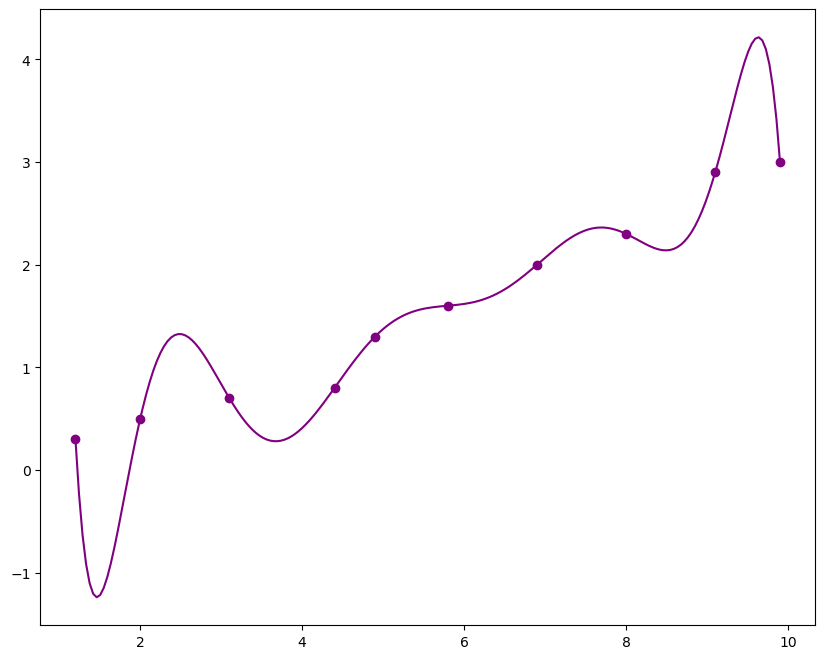

In [10]:
import numpy as np
from numpy import linalg as la
from math import *
from numpy.linalg import norm
import numpy as np
import matplotlib.pyplot as plt


#The given values
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9]) 
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

#make a list op powers
n = np.arange(0 , len(x), 1) 
#make a matrix of x each point to the powers of powers
R = x[:, np.newaxis] ** n 
a = np.linalg.solve(R, y) #solve the matrix y

#for the polynomial to create points for the x-axis so a nice grpah comes out
xpoly = np.linspace(min(x), max(x), 200) 

#make a function
poly =0
for i in range(len(a)): 
    poly += a[i] * (xpoly ** i)

fig, ax = plt.subplots(figsize= (10,8))

ax.scatter(x, y, color = 'purple')
ax.plot(xpoly, poly, color = 'purple')

plt.show()

Question 7.6

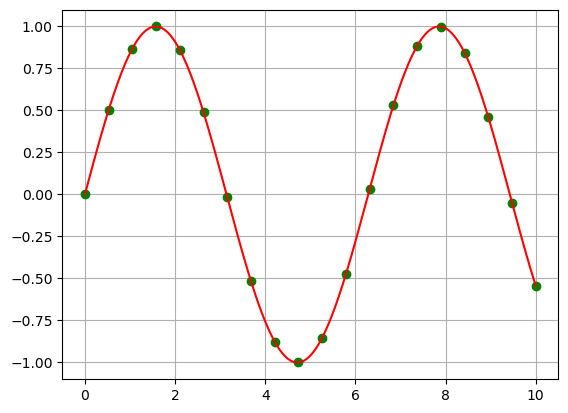

In [11]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.linspace(0,10,20)
y = np.sin(x)
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(0,10,250)  # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

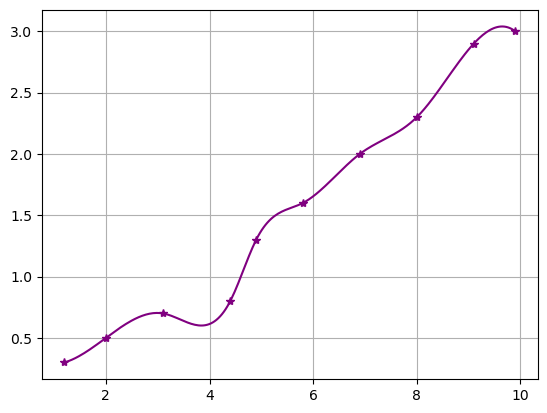

Input X value to find:  4
Input method (linear, poly, spline):  linear


Result: 0.7692307692307692


In [29]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(x[0],x[-1],250)  # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, '*', color = 'purple')
frame.plot(newx, newy, color = 'purple')
frame.grid()
show()

#We mentioned that this is a superior choice than the polynomial interpolation. Compared to the plot you make in Question 7.5, share your thought.
#It is much nicer since it has far lees and big oscillations which makes interpolations which makes the plot more usefull

class interpolation:
    def __init__(self, x, y, X): 
        self.x = np.array(x)
        self.y = np.array(y)
        self.X = X

        #definition for the linear one
    def linear(self):
        f = ip.interp1d(self.x, self.y, kind='linear') #interpoled
        linx = np.linspace(min(self.x),max(self.x),250) #make a line
        liny = f(newx)
        return linx, liny
        
    #definition for the polunomial one
    def polynomial(self):
        #creating powers
        powers = np.arange(0 , len(self.x), 1) 
        #make a matrix of x each point to the powers of powers
        A = self.x[:, np.newaxis] ** powers
        #using linalg solve
        a = np.linalg.solve(A, self.y) 
        #creating a lot of datapoints between each given data point so we get a nice groag
        xpol = np.linspace(min(self.x), max(self.x), 200) 
        ypol = 0
        #making a function
        for i in range(len(a)): 
            ypol += a[i] * (xpol ** i)
        return polx, poly
        
    #definition for the spline/cubic one
    def spline(self):
        f = ip.interp1d(self.x, y, kind='cubic') 
        splinex = np.linspace(min(self.x),max(self.x),250) 
        spliney = f(newx)
        return splinex, spliney
        
   #def to find a singular value
    def find_y(self, method):
        if method == 'linear':
            f = ip.interp1d(self.x, self.y, kind='linear')
            return float(f(self.X))
           
        elif method == 'poly':
            powers = np.arange(0, len(self.x))
            A = self.x[:, np.newaxis] ** powers
            coeffs = np.linalg.solve(A, self.y)
            return sum(c * (self.X ** i) for i, c in enumerate(coeffs))
           
        elif method == 'spline':
            f = ip.interp1d(self.x, self.y, kind='cubic')
            return float(f(self.X))




#let user input value/method
X = float(input('Input X value to find: '))
method_input = input('Input method (linear, poly, spline): ')

#get the answer
ans = interpolation(x,y,X)

print("Result:", ans.find_y(method_input))

Question 7.7

In [40]:
import numpy as np

#The entire def was copy pasted from the given notebook, as instructed by the session quiz
def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

#giving the requested np.array
I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

#changing the values to what we wanted
row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

#here we interpolate the given array
Iintp = bilinearIP(I, col_x, row_y)

if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")



[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


Question 7.10

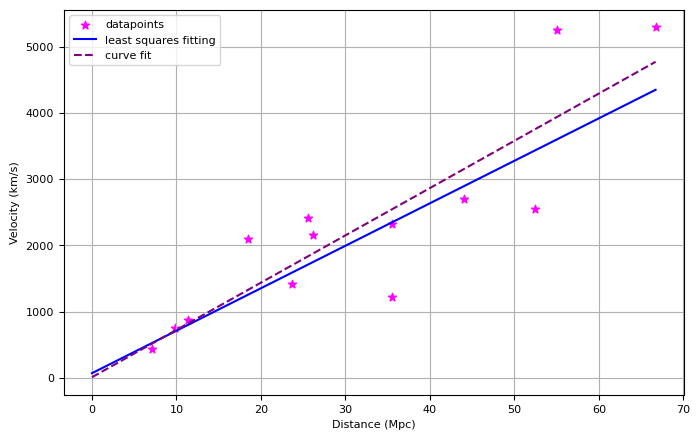

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit
import numpy as np
from scipy.optimize import leastsq

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]



x = np.array(data[0::4]) # distance in Mpc
y = np.array(data[1::4]) #velocity in km/s
sigx = data[2::4] #error in d
sigy = data[3::4] #error in v

#least squares fitting method
def model_for_lsq(beta, x):
    return beta[0] + beta[1] * x

def residuals(beta, x, y, sigy):
    return (y - model_for_lsq(beta, x)) / sigy

beta_start = [0, 70.0]

res_lsq = leastsq(residuals, beta_start, args=(x, y, sigy))
beta_weighted = res_lsq[0]

# curve fitting method
def model_for_cf(x, b0, b1):
    return b0 + b1 * x

beta_normal, _ = curve_fit(model_for_cf, x, y)


plt.figure(figsize=(8, 5))
plt.scatter(x, y, marker='*', color ='magenta',label="datapoints")


x_range = np.array([0, x.max()]) #create x-valies

y_weighted = model_for_lsq(beta_weighted, x_range) # least squares fitting
plt.plot(x_range, y_weighted, color='blue', label='least squares fitting')


y_normal = model_for_cf(x_range, *beta_normal) #curve fit
plt.plot(x_range, y_normal, color='purple', linestyle='--', label="curve fit")

plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid(True)
plt.show()

Question 7.14

Week 8 question 8.1